In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

path = "C:/Users/Mohamedragab/OneDrive/Desktop/team 5/Final_User_Behavior_Analysis.csv"
df = pd.read_csv(path)

df.head()

,User_ID,Device_Model,Operating_System,App_Usage_Time,Screen_On_Time,Battery_Drain,Number_of_Apps_Installed,Data_Usage,Age,Gender,User_Behavior_Class,Battery_Intensity,User_Status,App_Distraction_Index,Battery_Stress_Score,Generation,Usage_Efficiency,Digital_Burnout_Score,User_Persona,Battery_Efficiency_Level,Extreme_Usage_Flag,Risk_Score,Addiction_Risk_Level
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4,292.50,Heavy,5.87,0.599359,Millennials,1.023438,4.29,Male - Millennials,High Drain,Normal,55.116540,Medium Risk
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3,283.19,Regular,6.38,0.709241,Gen X / Boomers,0.950355,1.97,Female - Gen X / Boomers,Low Drain,Normal,39.735549,Low Risk
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2,190.25,Casual,4.81,0.423127,Gen X / Boomers,0.641667,1.28,Male - Gen X / Boomers,Low Drain,Normal,26.898945,Low Risk
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3,349.17,Regular,4.27,0.519690,Gen Z,0.829861,2.69,Male - Gen Z,High Drain,Normal,43.434254,Medium Risk
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3,317.91,Regular,3.22,0.722751,Millennials,0.724806,2.49,Female - Millennials,Low Drain,Normal,43.779335,Medium Risk


In [3]:
# Preprocessing - Clean Column Names
df.columns = [c.split(' (')[0].replace(' ', '_') for c in df.columns]

print(df.columns.tolist())

['User_ID', 'Device_Model', 'Operating_System', 'App_Usage_Time', 'Screen_On_Time', 'Battery_Drain', 'Number_of_Apps_Installed', 'Data_Usage', 'Age', 'Gender', 'User_Behavior_Class', 'Battery_Intensity', 'User_Status', 'App_Distraction_Index', 'Battery_Stress_Score', 'Generation', 'Usage_Efficiency', 'Digital_Burnout_Score', 'User_Persona', 'Battery_Efficiency_Level', 'Extreme_Usage_Flag', 'Risk_Score', 'Addiction_Risk_Level']


In [4]:
# Handle Missing Values

for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

df.isnull().sum().sum()

0

In [6]:
# Feature Engineering

df['Battery_Intensity'] = df['Battery_Drain'] / df['Screen_On_Time']

behavior_map = {1:'Basic', 2:'Casual', 3:'Regular', 4:'Heavy', 5:'Addicted'}
df['User_Status'] = df['User_Behavior_Class'].map(behavior_map)

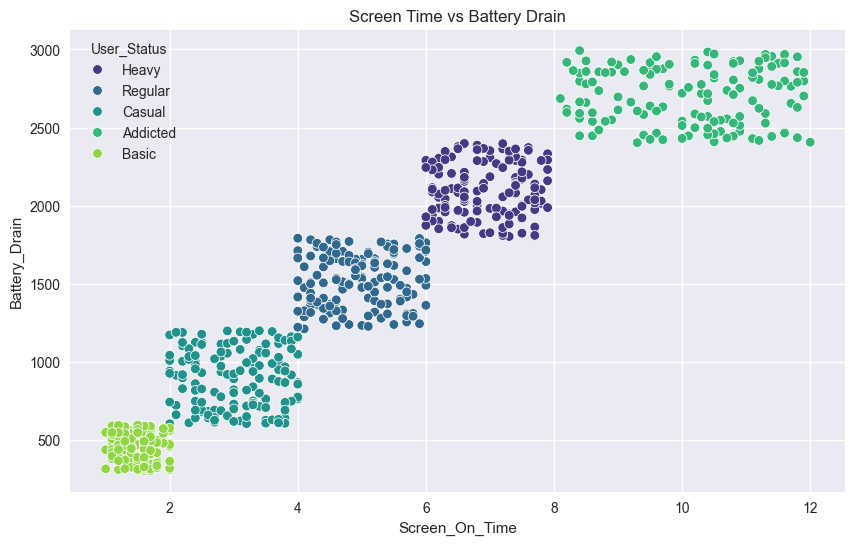

In [7]:
# Data Visualization

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Screen_On_Time', y='Battery_Drain', hue='User_Status', palette='viridis')
plt.title('Screen Time vs Battery Drain')
plt.show()

In [8]:
# Advanced Feature Engineering

df['App_Distraction_Index'] = df['App_Usage_Time'] / df['Number_of_Apps_Installed']

df['Battery_Stress_Score'] = df['Data_Usage'] / df['Battery_Drain']

def get_generation(age):
    if age <= 24:
        return 'Gen Z'
    elif age <= 40:
        return 'Millennials'
    else:
        return 'Gen X / Boomers'

df['Generation'] = df['Age'].apply(get_generation)

df['Usage_Efficiency'] = (df['App_Usage_Time'] / 60) / df['Screen_On_Time']

df[['Age', 'Generation', 'App_Distraction_Index', 'Battery_Stress_Score']].head()

,Age,Generation,App_Distraction_Index,Battery_Stress_Score
0,40,Millennials,5.865672,0.599359
1,47,Gen X / Boomers,6.380952,0.709241
2,42,Gen X / Boomers,4.812500,0.423127
3,20,Gen Z,4.267857,0.519690
4,31,Millennials,3.224138,0.722751


In [9]:
# Behavioral Insights Features

df['Digital_Burnout_Score'] = (df['Screen_On_Time'] * df['Number_of_Apps_Installed']) / 100

df['User_Persona'] = df['Gender'] + " - " + df['Generation']

mean_drain = df['Battery_Drain'].mean()
df['Battery_Efficiency_Level'] = df['Battery_Drain'].apply(
    lambda x: 'High Drain' if x > mean_drain else 'Low Drain'
)

df[['User_Persona', 'Digital_Burnout_Score', 'Battery_Efficiency_Level']].head()

,User_Persona,Digital_Burnout_Score,Battery_Efficiency_Level
0,Male - Millennials,4.288,High Drain
1,Female - Gen X / Boomers,1.974,Low Drain
2,Male - Gen X / Boomers,1.280,Low Drain
3,Male - Gen Z,2.688,High Drain
4,Female - Millennials,2.494,Low Drain


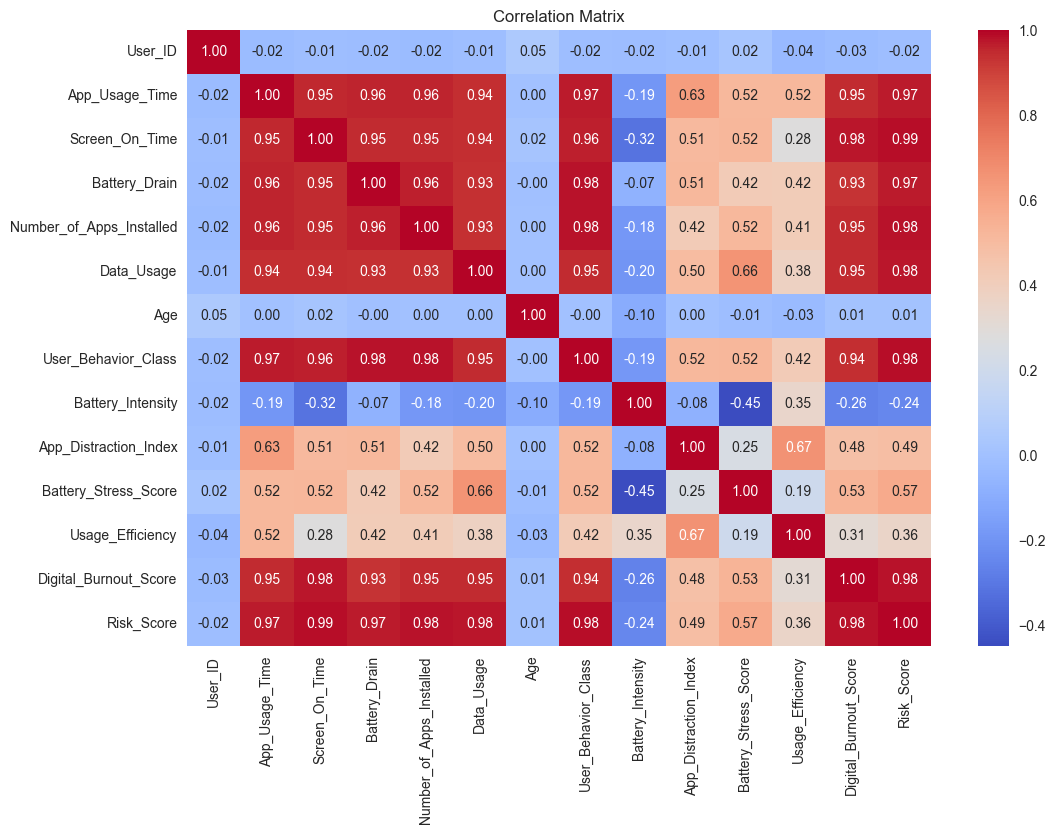

In [10]:
# Correlation Analysis

plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

In [11]:
# Data Type Formatting

df['Age'] = df['Age'].astype(int)
df['Number_of_Apps_Installed'] = df['Number_of_Apps_Installed'].astype(int)

df['Battery_Intensity'] = df['Battery_Intensity'].round(2)
df['Digital_Burnout_Score'] = df['Digital_Burnout_Score'].round(2)
df['App_Distraction_Index'] = df['App_Distraction_Index'].round(2)

print(df.dtypes)

User_ID                       int64
Device_Model                 object
Operating_System             object
App_Usage_Time                int64
Screen_On_Time              float64
Battery_Drain                 int64
Number_of_Apps_Installed      int32
Data_Usage                    int64
Age                           int32
Gender                       object
User_Behavior_Class           int64
Battery_Intensity           float64
User_Status                  object
App_Distraction_Index       float64
Battery_Stress_Score        float64
Generation                   object
Usage_Efficiency            float64
Digital_Burnout_Score       float64
User_Persona                 object
Battery_Efficiency_Level     object
Extreme_Usage_Flag           object
Risk_Score                  float64
Addiction_Risk_Level         object
dtype: object


C:\Users\Mohamedragab\AppData\Local\Temp\ipykernel_9372\2253668012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='User_Status', y='Screen_On_Time', palette='Set2')


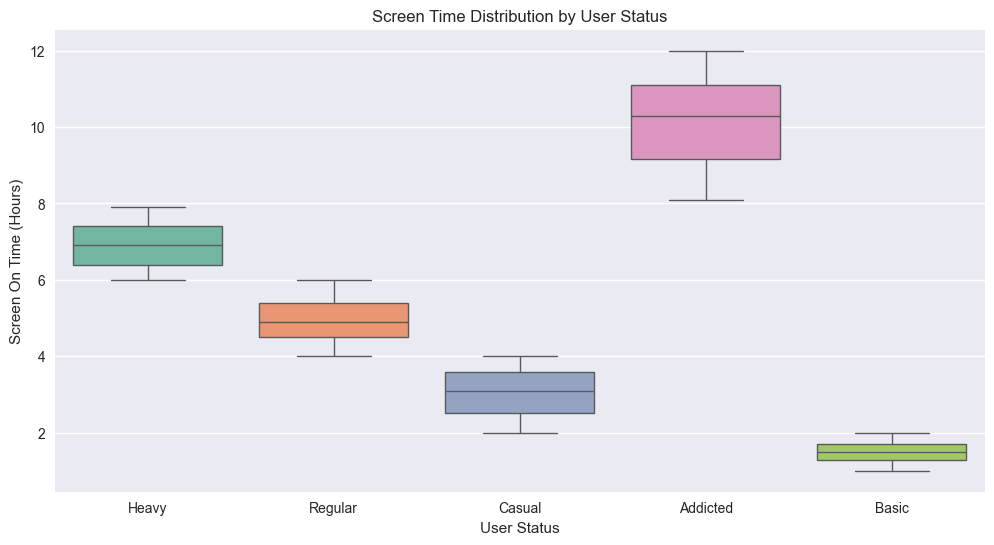

In [12]:
# Distribution Analysis

plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='User_Status', y='Screen_On_Time', palette='Set2')

plt.title('Screen Time Distribution by User Status')
plt.xlabel('User Status')
plt.ylabel('Screen On Time (Hours)')

plt.show()

In [13]:
# Extreme Usage Detection

screen_threshold = df['Screen_On_Time'].mean() + (2 * df['Screen_On_Time'].std())

df['Extreme_Usage_Flag'] = df['Screen_On_Time'].apply(
    lambda x: 'Extreme' if x > screen_threshold else 'Normal'
)

print(df[df['Extreme_Usage_Flag'] == 'Extreme'].shape[0])

19


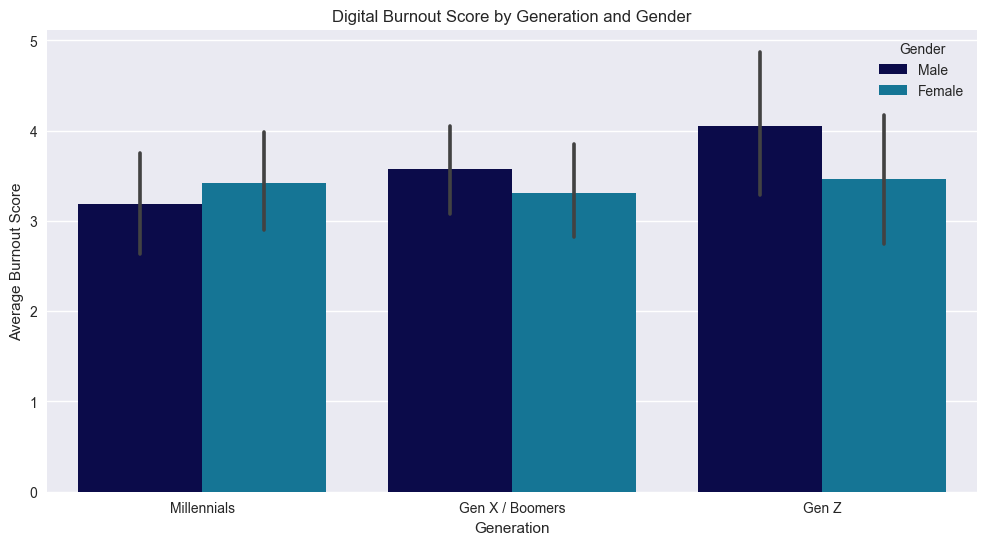

In [14]:
# Comparative Analysis

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x='Generation',
    y='Digital_Burnout_Score',
    hue='Gender',
    palette='ocean'
)

plt.title('Digital Burnout Score by Generation and Gender')
plt.ylabel('Average Burnout Score')

plt.show()

In [15]:
# Risk Scoring System

df['Risk_Score'] = (
    (df['Screen_On_Time'] / df['Screen_On_Time'].max()) * 40 +
    (df['Data_Usage'] / df['Data_Usage'].max()) * 30 +
    (df['Number_of_Apps_Installed'] / df['Number_of_Apps_Installed'].max()) * 30
)

def get_risk_level(score):
    if score >= 70:
        return 'High Risk'
    elif score >= 40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Addiction_Risk_Level'] = df['Risk_Score'].apply(get_risk_level)

print(df['Addiction_Risk_Level'].value_counts())


Addiction_Risk_Level
Low Risk       325
Medium Risk    239
High Risk      136
Name: count, dtype: int64


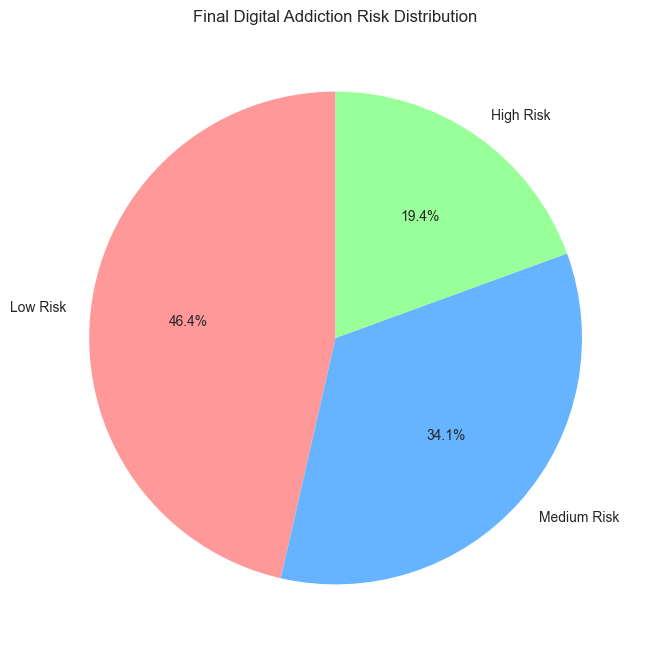

In [17]:
# Risk Distribution Visualization

plt.figure(figsize=(8, 8))

df['Addiction_Risk_Level'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff', '#99ff99'],
    startangle=90
)

plt.title('Final Digital Addiction Risk Distribution')
plt.ylabel('')

plt.show()

In [18]:
# Final Data Summary

final_summary = df[['Generation', 'User_Status', 'Addiction_Risk_Level']].describe()

print(f"Final Dataset Shape: {df.shape}")

df.tail()

Final Dataset Shape: (700, 23)


,User_ID,Device_Model,Operating_System,App_Usage_Time,Screen_On_Time,Battery_Drain,Number_of_Apps_Installed,Data_Usage,Age,Gender,User_Behavior_Class,Battery_Intensity,User_Status,App_Distraction_Index,Battery_Stress_Score,Generation,Usage_Efficiency,Digital_Burnout_Score,User_Persona,Battery_Efficiency_Level,Extreme_Usage_Flag,Risk_Score,Addiction_Risk_Level
695,696,iPhone 12,iOS,92,3.9,1082,26,381,22,Male,2,277.44,Casual,3.54,0.352126,Gen Z,0.393162,1.01,Male - Gen Z,Low Drain,Normal,25.456281,Low Risk
696,697,Xiaomi Mi 11,Android,316,6.8,1965,68,1201,59,Male,4,288.97,Heavy,4.65,0.611196,Gen X / Boomers,0.774510,4.62,Male - Gen X / Boomers,High Drain,Normal,57.702042,Medium Risk
697,698,Google Pixel 5,Android,99,3.1,942,22,457,50,Female,2,303.87,Casual,4.50,0.485138,Gen X / Boomers,0.532258,0.68,Female - Gen X / Boomers,Low Drain,Normal,22.490589,Low Risk
698,699,Samsung Galaxy S21,Android,62,1.7,431,13,224,44,Male,1,253.53,Basic,4.77,0.519722,Gen X / Boomers,0.607843,0.22,Male - Gen X / Boomers,Low Drain,Normal,12.297290,Low Risk
699,700,OnePlus 9,Android,212,5.4,1306,49,828,23,Female,3,241.85,Regular,4.33,0.633997,Gen Z,0.654321,2.65,Female - Gen Z,Low Drain,Normal,42.796422,Medium Risk


In [19]:
# Save Final Processed Dataset

df.to_csv('Final_User_Behavior_Analysis.csv', index=False)

print("Final_User_Behavior_Analysis.csv saved successfully.")

Final_User_Behavior_Analysis.csv saved successfully.


In [20]:
# Define Features and Target

X = df.drop(columns=['Addiction_Risk_Level'])
y = df['Addiction_Risk_Level']

X.head()

,User_ID,Device_Model,Operating_System,App_Usage_Time,Screen_On_Time,Battery_Drain,Number_of_Apps_Installed,Data_Usage,Age,Gender,User_Behavior_Class,Battery_Intensity,User_Status,App_Distraction_Index,Battery_Stress_Score,Generation,Usage_Efficiency,Digital_Burnout_Score,User_Persona,Battery_Efficiency_Level,Extreme_Usage_Flag,Risk_Score
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4,292.50,Heavy,5.87,0.599359,Millennials,1.023438,4.29,Male - Millennials,High Drain,Normal,55.116540
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3,283.19,Regular,6.38,0.709241,Gen X / Boomers,0.950355,1.97,Female - Gen X / Boomers,Low Drain,Normal,39.735549
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2,190.25,Casual,4.81,0.423127,Gen X / Boomers,0.641667,1.28,Male - Gen X / Boomers,Low Drain,Normal,26.898945
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3,349.17,Regular,4.27,0.519690,Gen Z,0.829861,2.69,Male - Gen Z,High Drain,Normal,43.434254
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3,317.91,Regular,3.22,0.722751,Millennials,0.724806,2.49,Female - Millennials,Low Drain,Normal,43.779335


In [ ]:
# Encoding

X = pd.get_dummies(X, drop_first=True)

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9928571428571429

Confusion Matrix:
 [[23  0  0]
 [ 0 65  1]
 [ 0  0 51]]

Classification Report:
               precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00        23
    Low Risk       1.00      0.98      0.99        66
 Medium Risk       0.98      1.00      0.99        51

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140



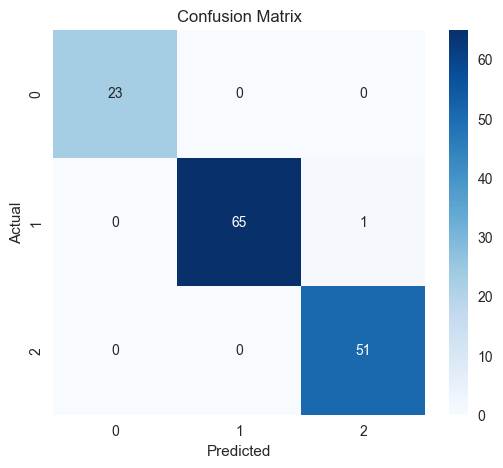

In [26]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()